 
<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

---
 
# **PROCESAMIENTO DEL LENGUAJE NATURAL:** 

**EXAMEN 1: Entre Alhóndigas, Besos y Momias; Crónica de un Examen Anunciado.**
===
EZAU FARIDH TORRES TORRES.
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>
<p align="right"> Fecha de entrega: 11/04/2025. </p>


---

In [1]:
# Necessary libraries.
import numpy as np                             # library for numerical operations.
import matplotlib.pyplot as plt                # library for plotting.
import re
import matplotlib as mpl                       # library for plotting.
import torch                                   # library for tensor operations.
from nltk.tokenize import TweetTokenizer       # library for tweet tokenization.
from nltk.corpus import stopwords              # library for stopwords.
stopwords_es = set(stopwords.words('spanish')) # set of spanish stopwords.
import os                                      # library for operating system.
import time                                    # library for time.
from typing import Tuple, Callable, List       # library for typing.
import random                                  # library for random numbers.
import pandas as pd                            # library for data manipulation.
from collections import defaultdict, Counter   # library for collections.
from tqdm import tqdm                          # library for progress bar.
import torch.nn as nn                          # library for neural network operations.
import torch.nn.functional as F                # library for functional operations.
from torch.utils.data import (DataLoader,      # library for data loading.
                              Dataset)         # library for dataset.
from sklearn.metrics import (confusion_matrix,      # library for evaluation.
                             classification_report, # library for evaluation.
                             f1_score)              # library for evaluation.
from torch import optim                        # for neural networks.
from colorama import Fore, Style               # library for colored text.
import seaborn as sns                          # library for data visualization.
sns.set_style("darkgrid")                      # set style for seaborn.
import xml.etree.ElementTree as ET             # library for xml parsing.
from IPython.display import display, HTML      # library for displaying HTML.
np.random.seed(0)                              # seed for reproducibility.
random.seed(0)                                 # seed for reproducibility.
torch.manual_seed(0)                           # seed for reproducibility.
torch.backends.cudnn.benchmark = False         # reproducibility.

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from wordcloud import WordCloud

* * *
# **Contexto**

Realiza los siguientes puntos en un notebook de Python lo mejor organizado y claro posible. Ponga su nombre al notebook (e.g., adrian_pastor_lopez_monroy.ipynb) y también en la primera celda del notebook junto con el número de Tarea. Sube al classroom el notebook como un archivo, que deberá haber sido ejecutado en tú máquina y mostrar el resultado en las celdas.

Para este proyecto consideraremos el conjunto de datos recolectado por el equipo del Dr. Rafael Guerrero, profesor en la División de Ciencias Económico Administrativas de la Universidad de Guanajuato. Este conjunto de datos contiene un aproximado de diez mil opiniones de turistas en trip advisor en 10 sitios turísticos de la ciudad de Guanajuato. **El objetivo es realizar las siguientes actividades y contestar las preguntas.** Para esta tarea se puede usar cualquier librería o herramienta de Python (e.g., sklearn, keras, nltk, códigos de github de otras personas (citando), etc.). También puede reusar su código de tareas previas, o puede simplemente usar TfIdfVectorizer, CountVectorizer, etc. de sklearnt. Puede usar también SelectKBest como en el Lecture de DOR lo hizo el profesor, o usar su propio código de $Chi2^{1}$

Para estas actividades usted determine el número de features (palabras) de alguna forma según su intuición. Usualmente el top $10k$ con base en frecuencia podría ser buena elección si su hardware es suficiente para llevar a cabo las actividades. Sí su reducción es a $5k$ o menos términos, algo con base en $Chi2$, Ganancia de Información o valores *TFIDFs* podría venir mejor para no perder tanta información y llegar a buenas conclusiones. Este Proyecto Examen es INDIVIDUAL Y NO SE VALE COPIAR.

* * *
# **1.- Actividades (50pts)**

## **1.1.- (2.5pts) Construya estadísticas básicas respecto a la opinión de cada lugar turístico. Preprocese y limpie el texto según sus intuiciones y argumente brevemente sobre ello. Considere scores de 4 a 5 como positivos, calificaciones de 3 como neutros y las de 2 a 1 como negativos. Es interesante ver algunos datalles a continuación.**

> Primero, asumiendo que cada pestaña se guardó como CSV y se encuentran en el directorio **./data/**, cargamos una lista de los nombres de estos archivos en la variable *csv_files* que usaremos en todo el notebook:


In [2]:
folder_path = './data'
csv_files = [f.replace('.csv', '') for f in os.listdir(folder_path)]
print('Archivos CSV encontrados:')
print(csv_files)

Archivos CSV encontrados:
['JardindelaUnion1134', 'UniversidaddeGuanajuato900', 'MonumentoPipila1620', 'CallejondelBeso1360', 'Alhondiga930', 'BasilicaColegiata560', 'CasadeDiegoRivera698', 'MercadoHidalgo600', 'MuseodelasMomias1650', 'TeatroJuarez1010']


> Ahora, se definen dos clases importantes: 
>
> 1. **TouristPlaceAnalyzer:**
> 
> Aquí se analizan las opiniones recopiladas en un archivo CSV dado. Carga automáticamente los datos, realiza una limpieza básica del texto, clasifica las opiniones según su tono (positivo, neutral o negativo). Tokeniza y genera un vocabulario de tamaño $10,000$ por default y genera su propio corpus (las opiniones del lugar). Además, se calculan las estadísticas generales pedidas en el ejercicio y más. Se generan visualizaciones sobre la edad de los visitantes, tipo de visitante, idioma de las opiniones, tipo de dispositivo usado para responder, top 10 países de procedencia, etc., es decir, hace todo el análisis pedido para un archivo CSV dado. 
>
>**NOTA: Se hace una descripción a fondo de cada método de la clase en su docstring y los métodos más importantes se van comentando conforme se van utilizando.**

In [16]:
class TouristPlaceAnalyzer:
    def __init__(self, filename: str, folder_path: str = 'data', max_vocab_size: int = 10000,
                 tokenizer: Callable = None, remove_stopwords: bool = False, stopwords_set: set = stopwords_es):
        """
        Initializes the TouristPlaceAnalyzer class.

        Parameters
        ----------
        filename : str
            The name of the CSV file to be analyzed (without the .csv extension).
        folder_path : str
            The path to the folder containing the CSV files.
        max_vocab_size : int
            The maximum size of the vocabulary to be built from the reviews.
        tokenizer : Callable, optional
            A custom tokenizer function. If None, a default TweetTokenizer is used.
        remove_stopwords : bool, optional
            Whether to remove stopwords from the reviews. Default is False.
        stopwords_set : set, optional
            A set of stopwords to be used for filtering. Default is Spanish stopwords from NLTK.
        """
        self.filename = filename                                      # name of the CSV file.
        self.file_path = os.path.join(folder_path, filename + '.csv') # path to the CSV file.
        self.formal_name = self.get_formal_name()                     # get the formal name of the tourist place.
        self.df = self.create_csv()                                   # create a pandas dataframe from the CSV file.
        self.preprocessed_text()                                      # preprocess the text data in the dataframe.
        self.corpus = self.df['Opinión'].dropna().astype(str).tolist()

        # Tokenizer for text processing and additional parameters.
        self.tokenizer = tokenizer if tokenizer else TweetTokenizer(preserve_case = False, reduce_len = True, strip_handles = True)
        self.remove_stopwords = remove_stopwords
        self.stopwords = stopwords_set

        self.max_vocab_size = max_vocab_size # maximum size of the vocabulary.
        self.vocab = self.build_vocabulary() # build the vocabulary from the reviews.

    def get_formal_name(self) -> str:
        """
        Returns the formal name of the tourist place based on the filename for graph titles.
        """
        name = {
            'JardindelaUnion1134'        : 'Jardín de la Unión',
            'UniversidaddeGuanajuato900' : 'Universidad de Guanajuato',
            'MonumentoPipila1620'        : 'Monumento Pípila',
            'CallejondelBeso1360'        : 'Callejón del Beso',
            'Alhondiga930'               : 'Alhóndiga',
            'BasilicaColegiata560'       : 'Basílica Colegiata',
            'CasadeDiegoRivera698'       : 'Casa de Diego Rivera',
            'MercadoHidalgo600'          : 'Mercado Hidalgo',
            'MuseodelasMomias1650'       : 'Museo de las Momias',
            'TeatroJuarez1010'           : 'Teatro Juárez'
        }
        return name.get(self.filename, self.filename)

    def create_csv(self) -> pd.DataFrame:
        """
        Creates a pandas dataframe from the CSV file.
        
        Returns
        -------
        df : pd.DataFrame
            A pandas dataframe containing the data from the CSV file.
        """
        df = pd.read_csv(self.file_path, encoding = 'utf-8', quotechar = '"')
        df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst = True, errors = 'coerce')
        return df

    def preprocessed_text(self) -> None:
        """
        Preprocesses the text data in the dataframe. Cleans the opinion text, calculates the length of the
        opinion, and assigns a sentiment label based on the rating.
        """
        self.df['Opinión'] = self.df['Opinión'].astype(str).str.strip().str.replace(r'\s+', ' ', regex = True)
        self.df['Opinion_Length'] = self.df['Opinión'].str.len()
        self.df['Sentiment'] = self.df['Escala'].apply(
            lambda x: 'Positive' if x >= 4 else 'Neutral' if x == 3 else 'Negative'
        )

    def general_statistics(self) -> dict:
        """
        Returns general statistics of the reviews.
        """
        results = {
            'total_reviews'          : len(self.df),
            'mean_score'             : self.df['Escala'].mean(),
            'score_std'              : self.df['Escala'].std(),
            'mean_opinion_length'    : self.df['Opinion_Length'].mean(),
            'opinion_length_std'     : self.df['Opinion_Length'].std(),
            'national_visitors'      : (self.df['Nacional ó Internacional'] == 'Nacional').sum(),
            'international_visitors' : (self.df['Nacional ó Internacional'] == 'Internacional').sum(),
            'age_mean'               : self.df['Edad'].mean(),
            'age_std'                : self.df['Edad'].std(),
            'principal_language'     : self.df['Idioma'].mode()[0],
            'principal_device'       : self.df['Dispositivo'].mode()[0],
            'principal_country'      : self.df['País'].mode()[0],
        }
        return results

    def plot_age_histogram(self, ax = None, show: bool = False, **kwargs) -> None:
        """
        Plots a histogram of the ages of the reviewers.
        """
        data = self.df['Edad'].dropna().astype(float)
        if ax is None:
            fig, ax = plt.subplots(figsize = (8, 5))
        if show:
            color = 'blue'
        else:
            color = kwargs.pop('color', self.custom_color)
        ax.hist(data, color = color, edgecolor = 'black', bins = 20, **kwargs)
        ax.set_title(f'Ages - {self.formal_name}', fontsize = 12, fontweight = 'bold')
        ax.set_xlabel('Age', fontsize = 10)
        ax.set_ylabel('Frequency', fontsize = 10)

    def plot_visitor_nationality_histogram(self, ax = None, show: bool = False, **kwargs) -> None:
        """
        Plots a histogram of the visitor types (National or International).
        """
        counts = self.df['Nacional ó Internacional'].value_counts()
        if ax is None:
            fig, ax = plt.subplots(figsize = (8,5))
        if show:
            color = 'deepskyblue'
        else:
            color = kwargs.pop('color', self.custom_color)
        counts.plot(kind = 'bar', ax = ax, color = color, edgecolor = 'black')
        ax.set_title(f'Visitor Type - {self.formal_name}', fontsize = 12, fontweight = 'bold')
        ax.set_ylabel('Number of Reviews', fontsize = 10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 0)

    def plot_language_distribution(self, ax = None, show: bool = False, **kwargs) -> None:
        """
        Plots a histogram of the languages used in the reviews.
        """
        counts = self.df['Idioma'].value_counts()
        counts = counts.head(8) 
        if ax is None:
            fig, ax = plt.subplots(figsize = (8,5))
        if show:
            color = 'cyan'
        else:
            color = kwargs.pop('color', self.custom_color)
        counts.plot(kind = 'bar', ax = ax, color = color, edgecolor = 'black')
        ax.set_title(f'Languages Used - {self.formal_name}', fontsize = 12, fontweight = 'bold')
        ax.set_ylabel('Number of Reviews', fontsize = 10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)

    def plot_country_distribution(self, ax = None, show: bool = False, **kwargs) -> None:
        """
        Plots a histogram of the countries of the reviewers.
        """
        counts = self.df['País'].value_counts()
        counts = counts.head(8)  # Get the top 10 countries
        if ax is None:
            fig, ax = plt.subplots(figsize = (8, 5))
        if show:
            color = 'turquoise'
        else:
            color = kwargs.pop('color', self.custom_color)
        counts.plot(kind = 'bar', ax = ax, color = color, edgecolor = 'black')
        ax.set_title(f'Countries - {self.formal_name}', fontsize = 12, fontweight = 'bold')
        ax.set_ylabel('Number of Reviews', fontsize = 10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)

    def plot_gender_visitor(self, ax = None) -> None:
        """
        Plots a histogram of gender visitors
        """
        counts = self.df['Género'].value_counts()
        if ax is None:
            fig, ax = plt.subplots(figsize = (6, 6))
        counts.plot(kind = 'pie', ax = ax, autopct = '%1.1f%%', startangle = 90, textprops = {'fontsize': 10})
        ax.set_title(f'Gender Visitor - {self.formal_name}', fontsize = 12, fontweight = 'bold')
        ax.set_ylabel('')

    def plot_sentiment_distribution(self, ax = None) -> None:
        """
        Plots a bar chart of the sentiment distribution of the reviews.
        """
        counts = self.df['Sentiment'].value_counts()
        if ax is None:
            fig, ax = plt.subplots(figsize = (8, 5))
        counts = counts.reindex(['Positive', 'Neutral', 'Negative']).fillna(0)
        counts.plot(kind = 'bar', ax = ax, color = ['green', 'gray', 'red'], edgecolor = 'black')
        ax.set_title(f'Sentiment - {self.formal_name}', fontsize = 12, fontweight = 'bold')
        ax.set_ylabel('Number of Reviews', fontsize = 10)
        ax.set_xticklabels(counts.index, rotation = 0)

    def build_vocabulary(self) -> List[str]:
        """
        Builds the top vocabulary from the reviews.

        Parameters
        ----------
        max_vocab_size : int
            The maximum size of the vocabulary.

        Returns
        -------
        vocab : list of str
            The top vocabulary of words from the reviews.
        """
        all_tokens = []

        opinions = self.df['Opinión'].dropna().astype(str).tolist()
        for opinion in opinions:
            tokens = self.tokenizer.tokenize(opinion.lower())
            if self.remove_stopwords:
                tokens = [t for t in tokens if t not in self.stopwords_set]
            all_tokens.extend(tokens)

        fdist = Counter(all_tokens)
        vocab = [word for word, _ in fdist.most_common(self.max_vocab_size)]
        return vocab

    def plot_wordcloud(self, k: int = 50):
        """
        Plots a word cloud of the most informative words in the reviews for the given sentiment and the words
        are selected based on their information gain.

        Parameters
        ----------
        k : int
            The number of most informative words to be displayed in the word cloud.
        """
        sentiment_to_int = {'Negative': 0, 'Neutral': 1, 'Positive': 2} # map sentiment to integer.
        labels = self.df['Sentiment'].map(sentiment_to_int).tolist()    # map sentiment to integer.

        # Vectorize the corpus.
        vectorizer = CountVectorizer(vocabulary = self.vocab) # vectorizer for the vocabulary.
        X = vectorizer.fit_transform(self.corpus)             # vectorized corpus.
        feature_names = vectorizer.get_feature_names_out()    # feature names.

        # Information gain per word.
        mi = mutual_info_classif(X, labels, discrete_features = True) # information gain.
        word_mi = dict(zip(feature_names, mi))                        # word information gain.

        # Sort the words by information gain and select the top-k.
        top_k_words = dict(sorted(word_mi.items(), key = lambda x: x[1], reverse = True)[:k])

        # Crear la nube
        wordcloud = WordCloud(
            width = 1200, height = 600, background_color = 'black', colormap = 'winter',
            max_words = k).generate_from_frequencies(top_k_words)

        plt.figure(figsize = (14,7), facecolor = 'black')
        plt.imshow(wordcloud, interpolation = 'bilinear')
        plt.axis("off")
        plt.title(f"Top {k} palabras informativas - {self.formal_name}", fontsize = 16, color = 'white')
        plt.tight_layout(pad = 0)
        plt.show()

> Y se podría generar una instancia para cada uno, describir su información y 10 gráfias cada que se necesiten, pero mejor se implementa:
>
> 2. **MultiPlaceAnalyzer:**
>
> Aquí se analizan los $10$ archivos CSV en lugar de uno por uno. Al inicializarse, se crea una lista de los objetos TouristPlaceAnalyzer. Se implementa el método *print_statistics()* que imprime estadísticas generales. Además, se tiene el método *plot_graphs()*, que permite visualizar histogramas de variables como edad, nacionalidad, idioma, país, género o sentimiento de los visitantes, distribuyéndolos en una cuadrícula para ver las $10$ localidades.

In [5]:
class MultiPlaceAnalyzer:
    def __init__(self, filenames: List[str], folder_path: str = 'data'):
        """
        Initializes the MultiPlaceAnalyzer class.
        
        Parameters
        ----------
        filenames : List[str]
            List of CSV filenames to be analyzed (without the .csv extension).
        folder_path : str
            The path to the folder containing the CSV files.
        """
        self.analyzers = [TouristPlaceAnalyzer(f, folder_path) for f in filenames] # list of analyzers.
        self.formal_names = [a.formal_name for a in self.analyzers]                # list of formal names.

        color_palette = plt.get_cmap('tab10')
        self.colors = [color_palette(i) for i in range(len(self.analyzers))]
        for analyzer, color in zip(self.analyzers, self.colors):
            analyzer.custom_color = color  

    def print_statistics(self, metric = 'all_info') -> None:
        """
        Prints the statistics of the reviews for each tourist place.

        Parameters
        ----------
        metric : str
            The metric to be printed. Options are 'score', 'length', or 'all_info'.
        """
        max_len = max(len(analyzer.formal_name) for analyzer in self.analyzers) + 1
        print(f'--- Estadísticas de calificación: ---\n') if metric == 'score' else None
        print(f'--- Estadísticas de longitud de opiniones: ---\n') if metric == 'length' else None
    
        for analyzer in self.analyzers:
            stats = analyzer.general_statistics()
            name = analyzer.formal_name
    
            if metric == 'score':
                print(f"{name:<{max_len}}: Mean = {stats['mean_score']:.2f}, Std = {stats['score_std']:.2f}")
            
            elif metric == 'length':
                print(f"{name:<{max_len}}: Mean = {stats['mean_opinion_length']:.2f}, Std = {stats['opinion_length_std']:.2f}")
    
            elif metric == 'all_info':
                print(f'--- Estadísticas generales para {name}: ---\n')
                print(f"   Total reviews          : {stats['total_reviews']}")
                print(f"   Mean score             : {stats['mean_score']:.2f}")
                print(f"   Score std              : {stats['score_std']:.2f}")
                print(f"   Mean opinion length    : {stats['mean_opinion_length']:.2f}")
                print(f"   Opinion length std     : {stats['opinion_length_std']:.2f}")
                print(f"   National visitors      : {stats['national_visitors']}")
                print(f"   International visitors : {stats['international_visitors']}")
                print(f"   Age mean               : {stats['age_mean']:.2f}")
                print(f"   Age std                : {stats['age_std']:.2f}")
                print(f"   Principal language     : {stats['principal_language']}")
                print(f"   Principal device       : {stats['principal_device']}")
                print(f"   Principal country      : {stats['principal_country']}")
                print()

    def plot_graphs(self, kind: str, sharey: bool = False, layout = (5,2), figsize = (16,10)) -> None:
        """
        Plots histograms for the specified kind of data for the 10 tourist places.
        """
        fig, axs = plt.subplots(*layout, figsize = figsize, sharey = sharey)

        axs = axs.flatten()    
        for idx, analyzer in enumerate(self.analyzers):
            ax = axs[idx]
            if kind == 'age':
                analyzer.plot_age_histogram(ax = ax, color = analyzer.custom_color)
            elif kind == 'nationality':
                analyzer.plot_visitor_nationality_histogram(ax = ax, color = analyzer.custom_color)
            elif kind == 'language':
                analyzer.plot_language_distribution(ax = ax, color = analyzer.custom_color)
            elif kind == 'country':
                analyzer.plot_country_distribution(ax = ax, color = analyzer.custom_color)
            elif kind == 'gender':
                analyzer.plot_gender_visitor(ax = ax)
            elif kind == 'sentiment':
                analyzer.plot_sentiment_distribution(ax = ax)
            else:
                ax.set_visible(False)
    
        for j in range(idx + 1, len(axs)):
            axs[j].set_visible(False)

        plt.suptitle(f'{kind.capitalize()} Distribution', fontsize = 16, fontweight = 'bold')
        plt.tight_layout()
        plt.show()

> Se crea la instancia de los $10$ sitios y se imprimen las estadísticas principales:

In [6]:
multi = MultiPlaceAnalyzer(filenames = csv_files,  folder_path = folder_path)
multi.print_statistics(metric = 'all_info')

--- Estadísticas generales para Jardín de la Unión: ---

   Total reviews          : 1134
   Mean score             : 4.59
   Score std              : 0.61
   Mean opinion length    : 248.62
   Opinion length std     : 202.88
   National visitors      : 572
   International visitors : 562
   Age mean               : 41.39
   Age std                : 14.89
   Principal language     : Español
   Principal device       : PC
   Principal country      : México

--- Estadísticas generales para Universidad de Guanajuato: ---

   Total reviews          : 900
   Mean score             : 4.60
   Score std              : 0.61
   Mean opinion length    : 208.56
   Opinion length std     : 115.31
   National visitors      : 573
   International visitors : 327
   Age mean               : 39.31
   Age std                : 13.93
   Principal language     : Español
   Principal device       : PC
   Principal country      : México

--- Estadísticas generales para Monumento Pípila: ---

   Total reviews 

### **a) Promedios de calificación por lugar, y desviaciones estándar en los scores.**

In [7]:
multi.print_statistics(metric = 'score')

--- Estadísticas de calificación: ---

Jardín de la Unión        : Mean = 4.59, Std = 0.61
Universidad de Guanajuato : Mean = 4.60, Std = 0.61
Monumento Pípila          : Mean = 4.38, Std = 0.77
Callejón del Beso         : Mean = 4.00, Std = 0.97
Alhóndiga                 : Mean = 4.45, Std = 0.75
Basílica Colegiata        : Mean = 4.50, Std = 0.67
Casa de Diego Rivera      : Mean = 4.24, Std = 0.80
Mercado Hidalgo           : Mean = 3.95, Std = 0.95
Museo de las Momias       : Mean = 3.68, Std = 1.14
Teatro Juárez             : Mean = 4.70, Std = 0.52


### **b) Basado en palabras: longitud promedio de opiniones y desviaciones estándar.**

In [8]:
multi.print_statistics(metric = 'length')

--- Estadísticas de longitud de opiniones: ---

Jardín de la Unión        : Mean = 248.62, Std = 202.88
Universidad de Guanajuato : Mean = 208.56, Std = 115.31
Monumento Pípila          : Mean = 264.39, Std = 199.06
Callejón del Beso         : Mean = 251.07, Std = 179.90
Alhóndiga                 : Mean = 271.72, Std = 193.49
Basílica Colegiata        : Mean = 227.14, Std = 163.98
Casa de Diego Rivera      : Mean = 277.13, Std = 166.79
Mercado Hidalgo           : Mean = 263.88, Std = 187.92
Museo de las Momias       : Mean = 327.49, Std = 259.59
Teatro Juárez             : Mean = 239.85, Std = 151.56


### **c) Histogramas de edades de opiniones por lugar.**

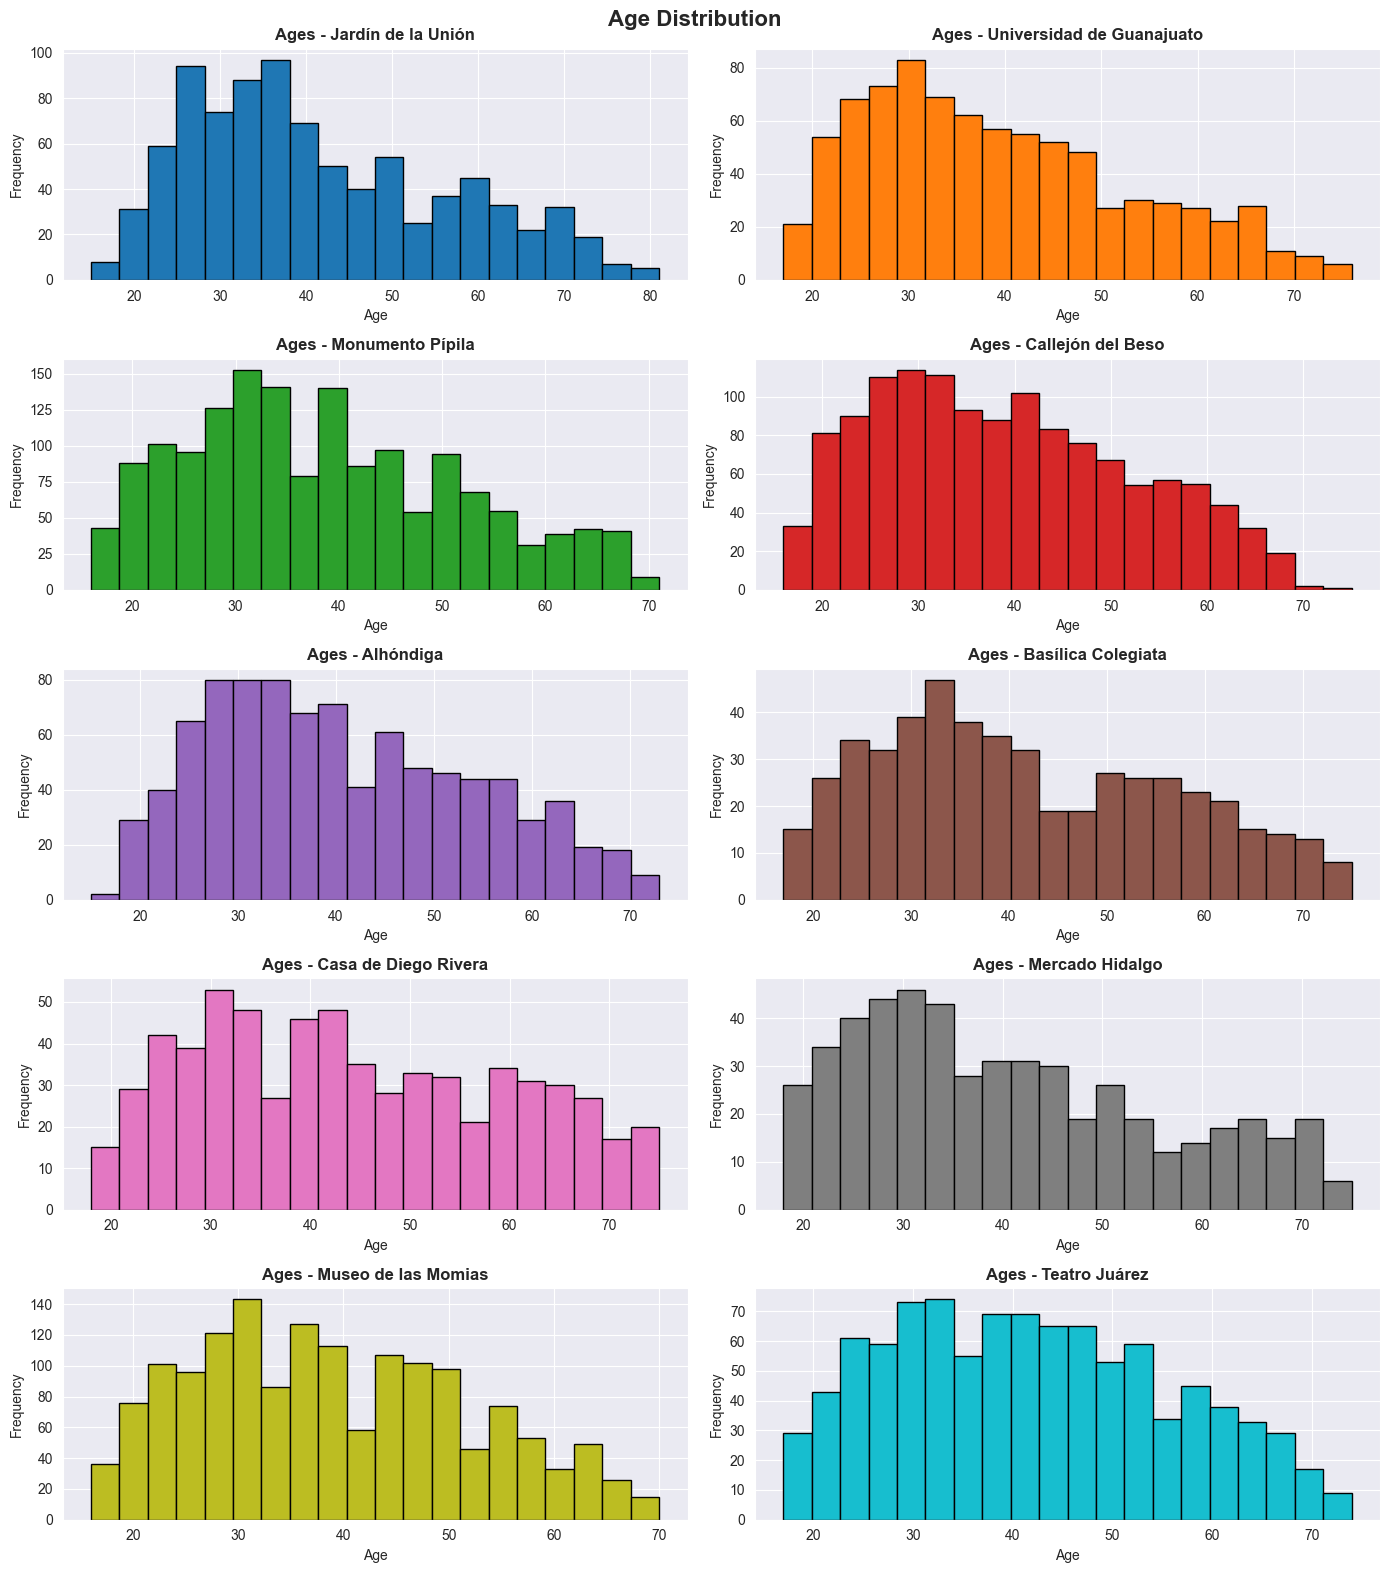

In [9]:
multi.plot_graphs(kind = 'age', figsize = (14,16))

### **d) Histograma de tipo de visitantes (nacional o internacional) por lugar.**

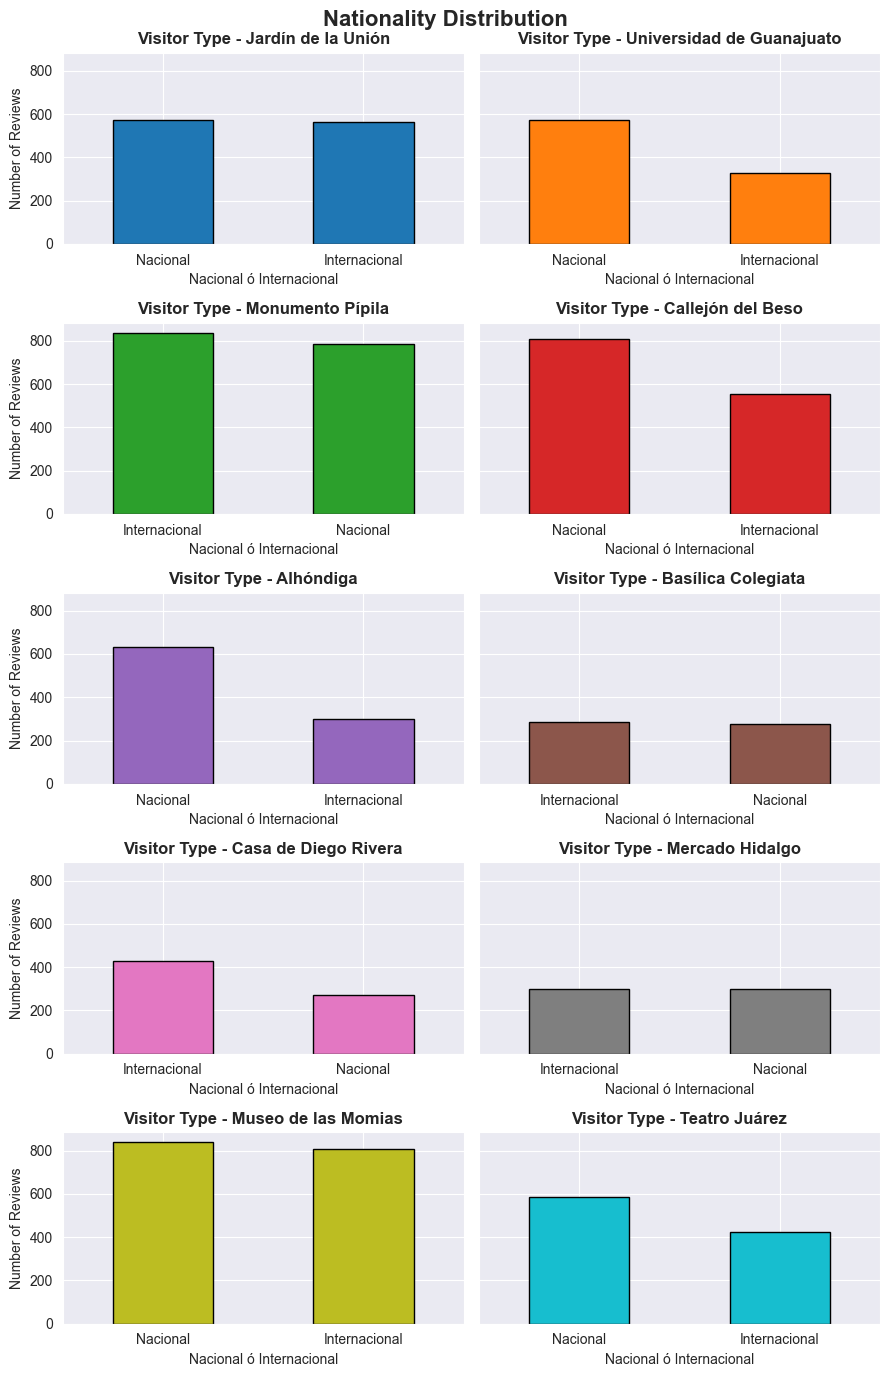

In [10]:
multi.plot_graphs(kind = 'nationality', figsize = (9,14), sharey = True)

### **e) Sugiere dos más interesantes para ti.**

> Veamos $4$ gráficos conjuntos más:

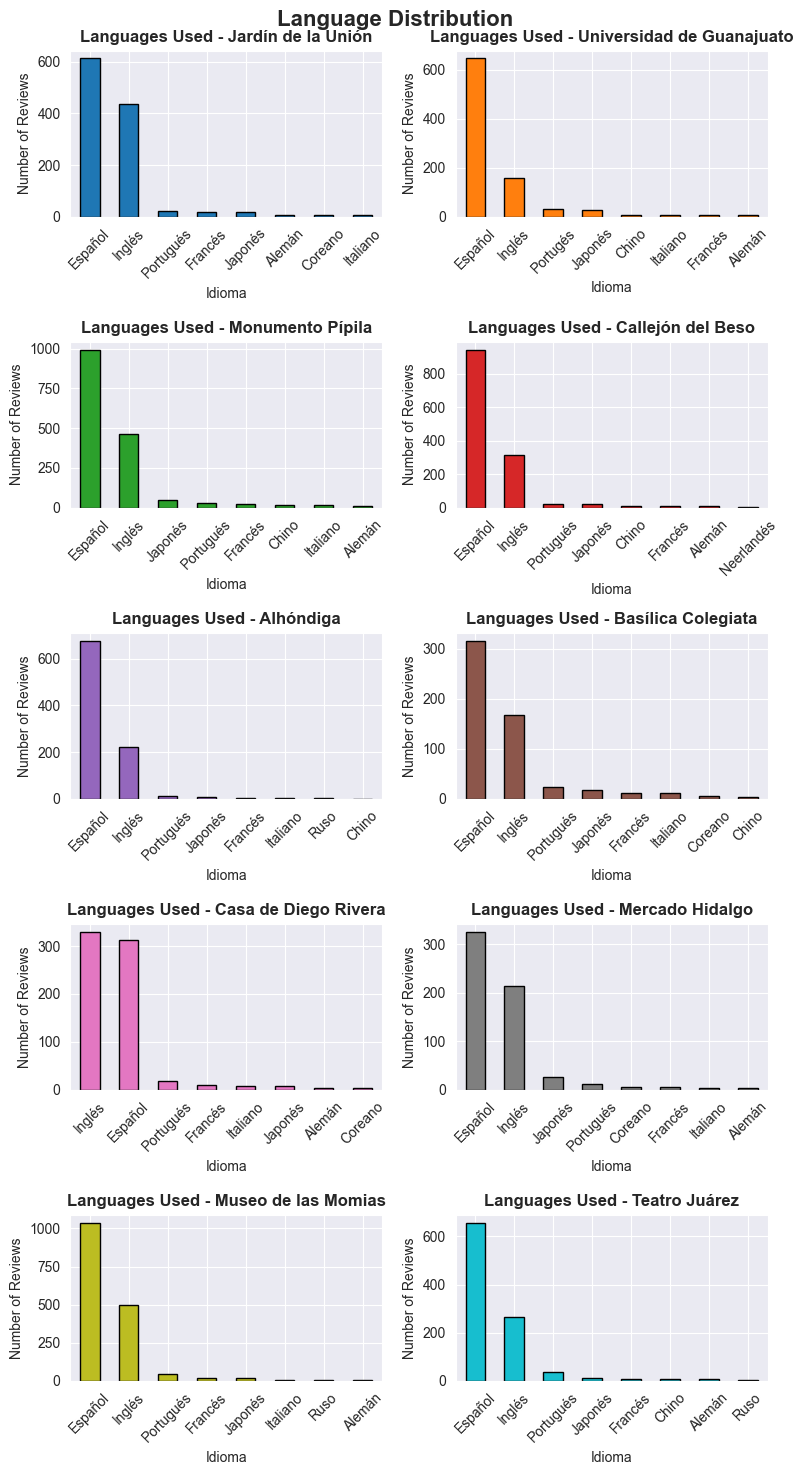

In [11]:
multi.plot_graphs(kind = 'language', figsize = (8,15))

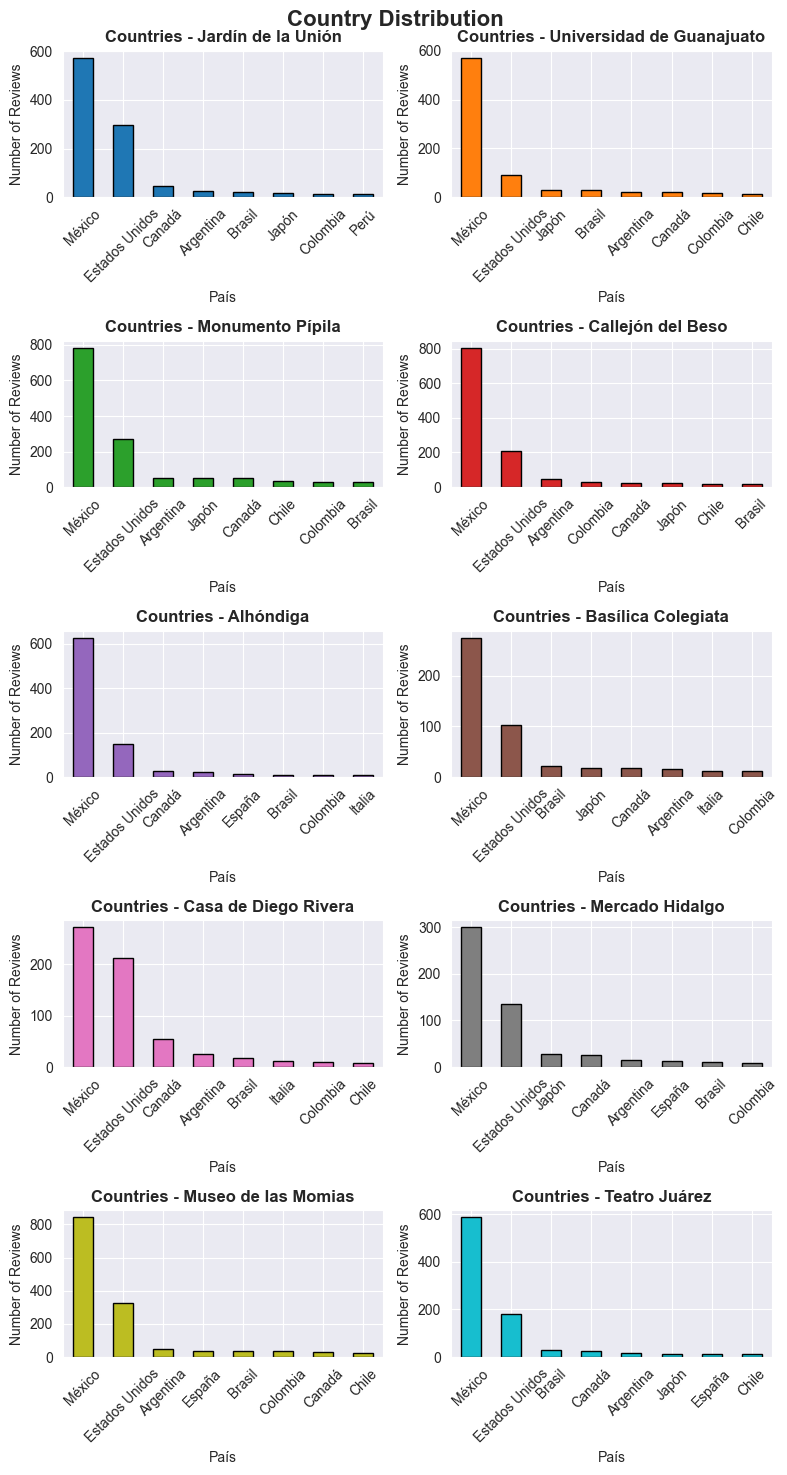

In [12]:
multi.plot_graphs(kind = 'country', figsize = (8,15))

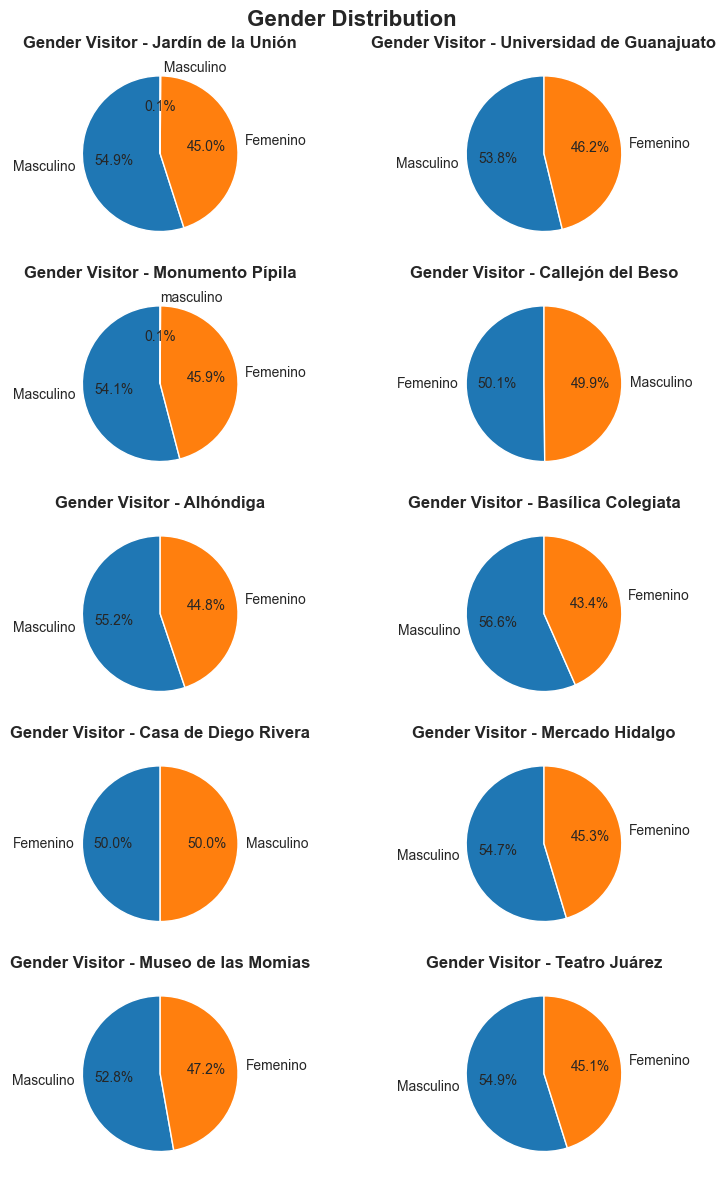

In [13]:
multi.plot_graphs(kind = 'gender', figsize = (8,12))

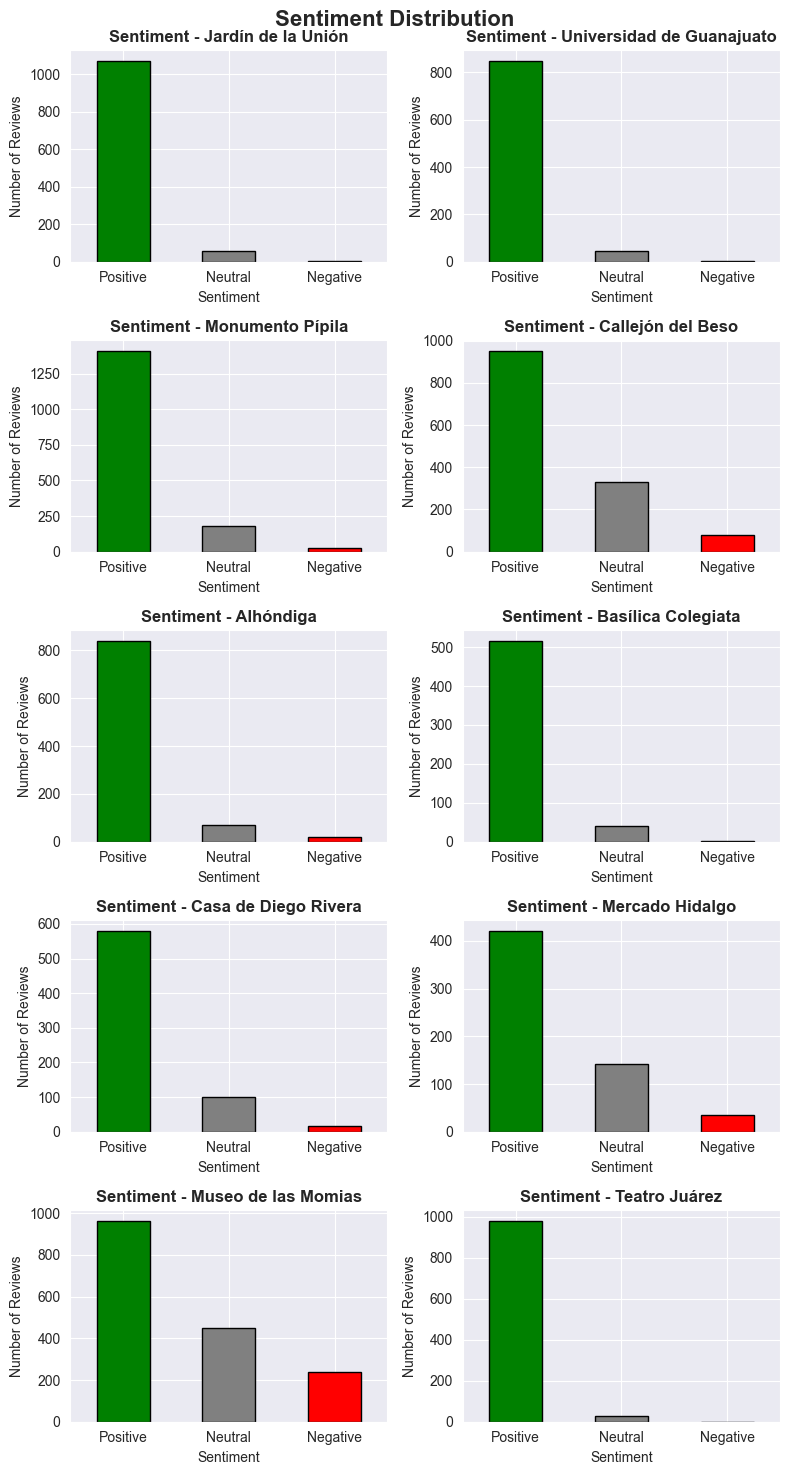

In [14]:
multi.plot_graphs(kind = 'sentiment', figsize = (8,15))

## **1.2.- (2.5pts) Utilizando una estrategia de feature selection (se sugiere $X^2$ o ganancia de información) visualice con *word_cloud* (https://amueller.github.io/word_cloud/) nubes de palabras el top $k$ (se sugiere $50$) de palabras más relevantes para cada uno de los $10$ lugares. Note que serán $10$ nubes, una por lugar.**

>En la clase *TouristPlaceAnalyzer* se implementa el método *plot_wordcloud()*, el cual genera una nube de palabras con las $k=50$ palabras más informativas (según su **ganancia de información**) que ayudan a distinguir entre sentimientos positivos, neutros y negativos de las opiniones turísticas de un solo lugar. A grandes rasgos, opera de la siguiente forma:
> 1. Transforma las opiniones (self.corpus) en una matriz de frecuencia de palabras (X), usando solo el vocabulario propio del lugar (self.vocab). Cada fila representa una opinión, y cada columna una palabra.
> 2. Usa la función *mutual_info_classif* de *sklearn*, que mide cuánta información aporta cada palabra sobre la clase (sentimiento).
> 3. Ordena las palabras según su ganancia de información se queda con las top $k=50$ palabras y genera la nube.

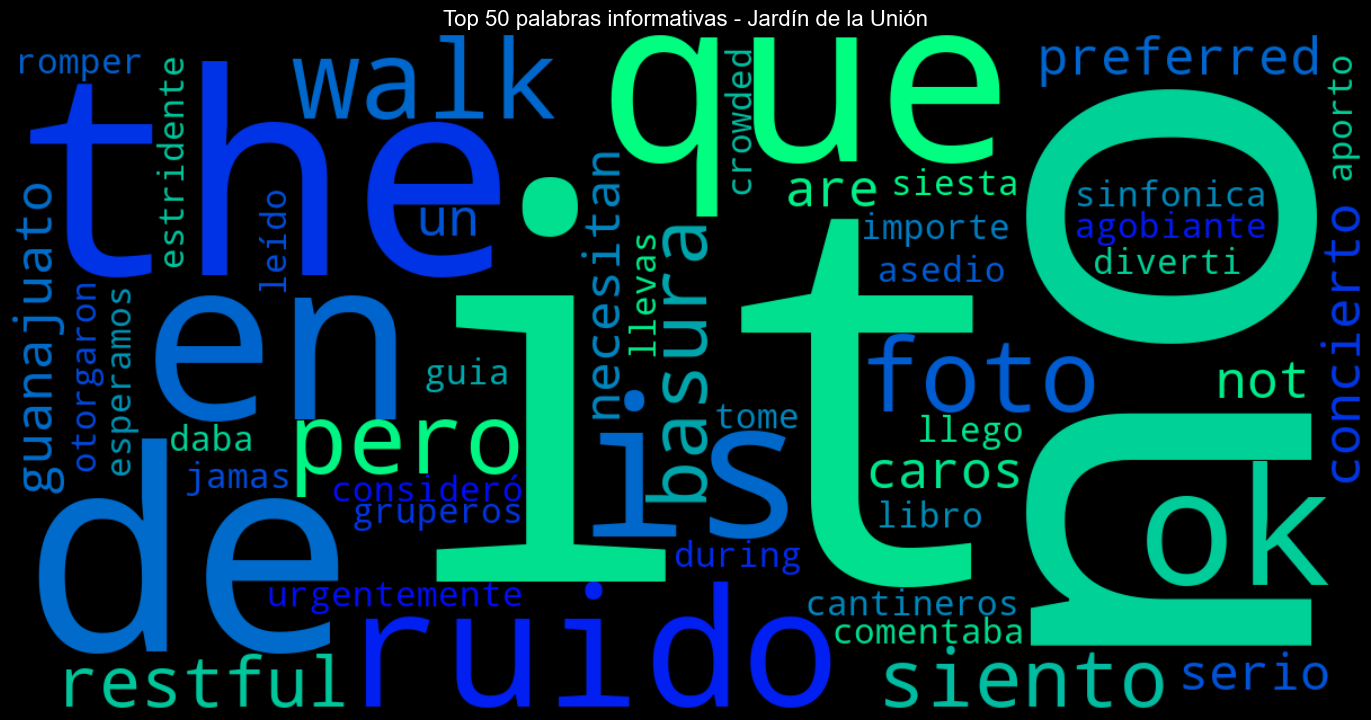

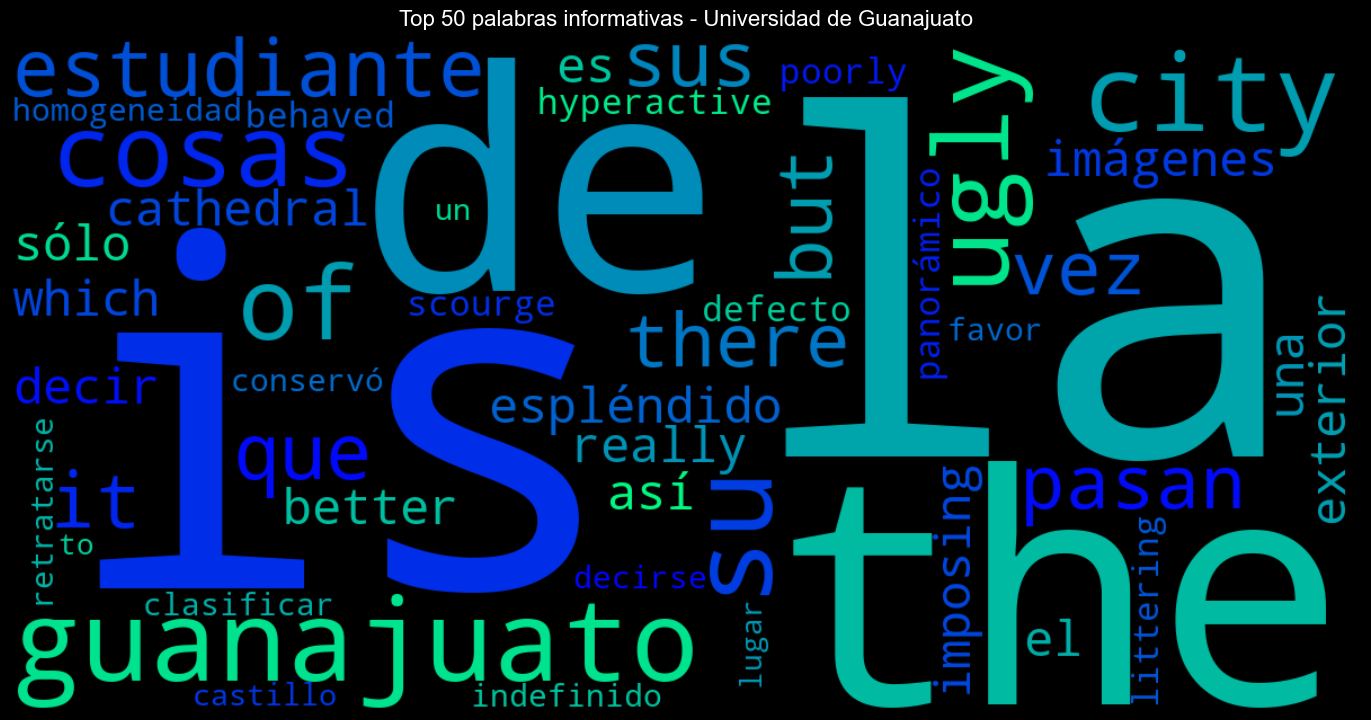

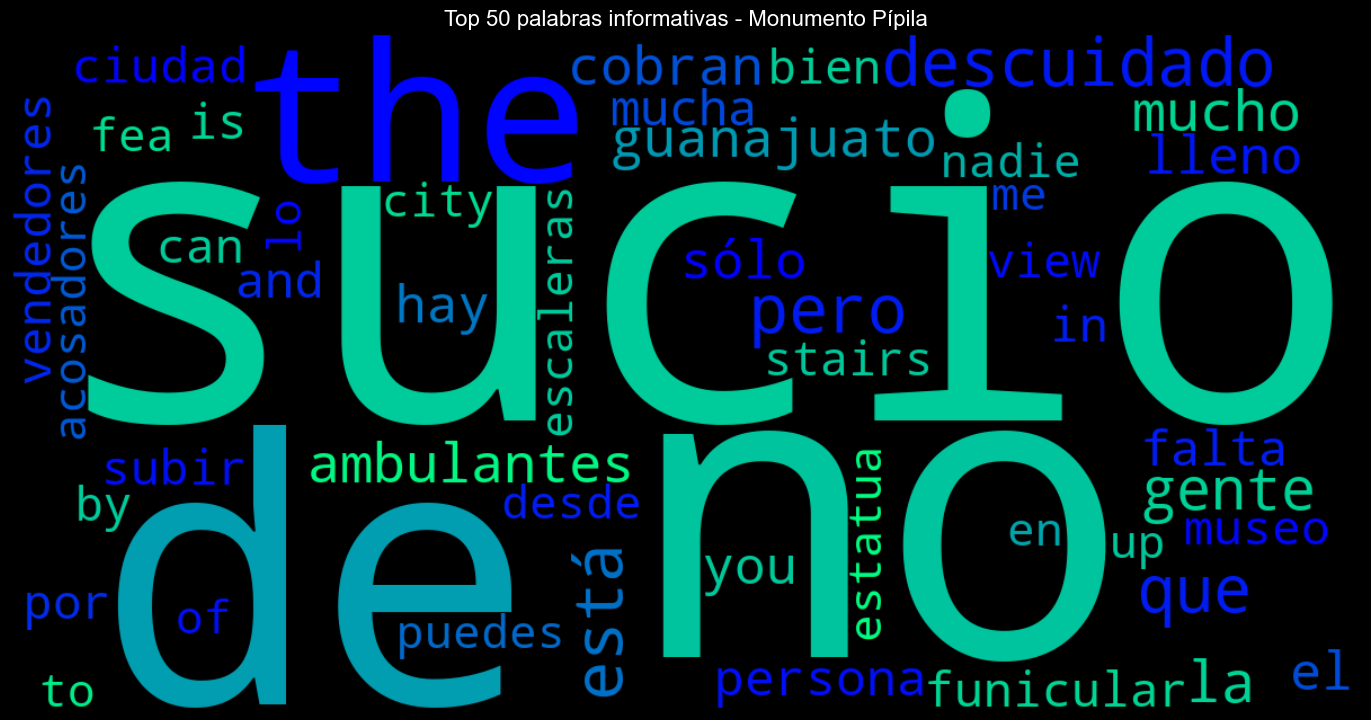

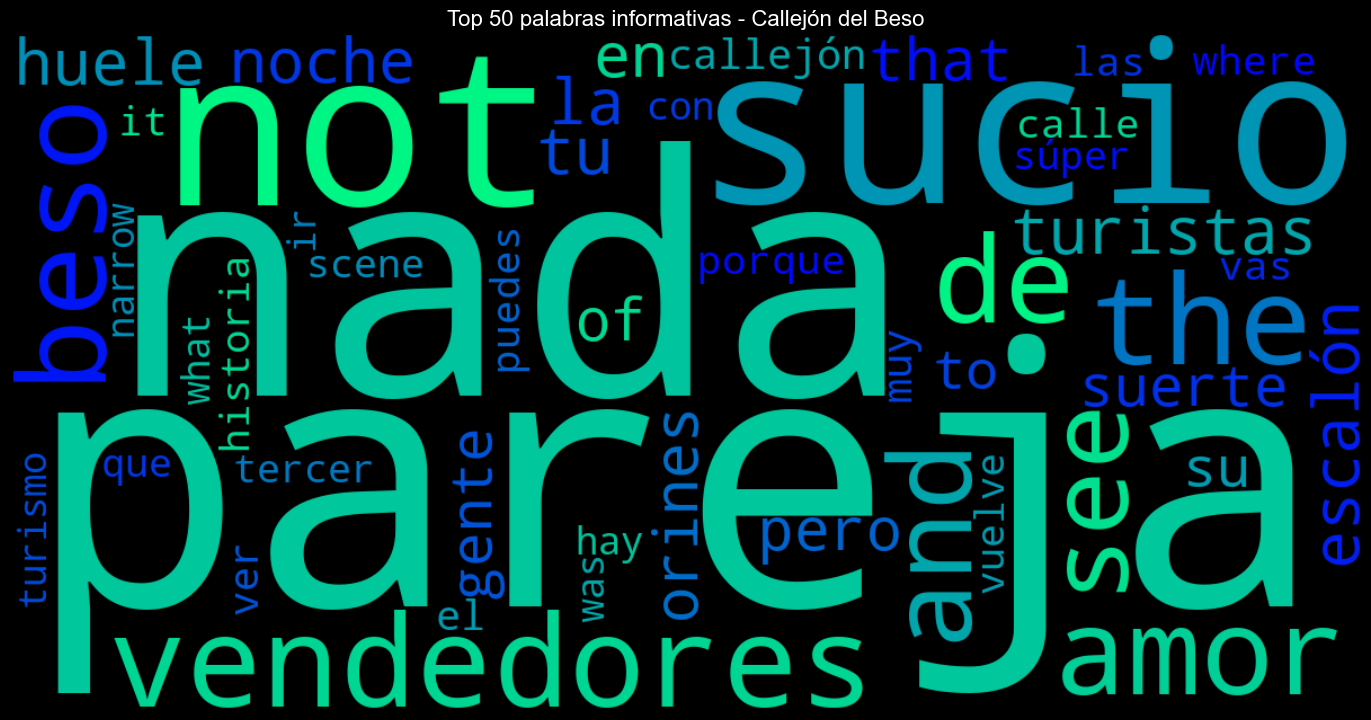

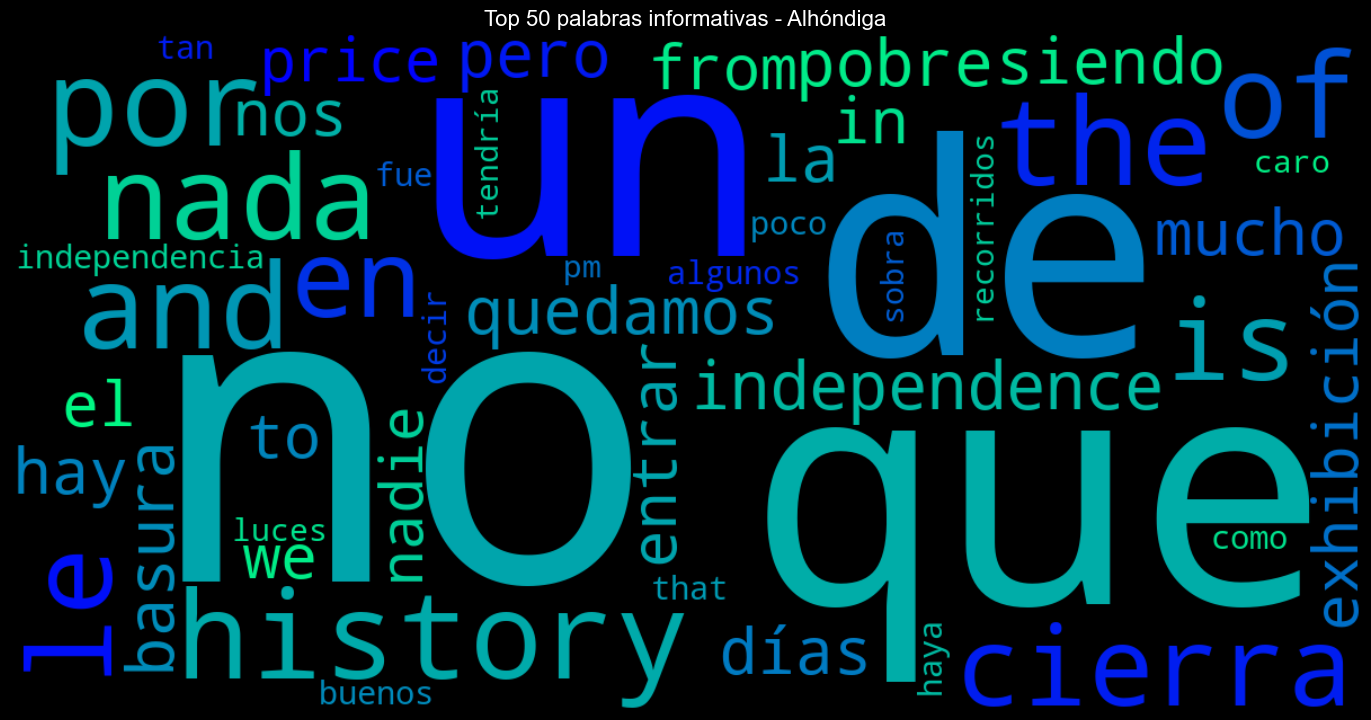

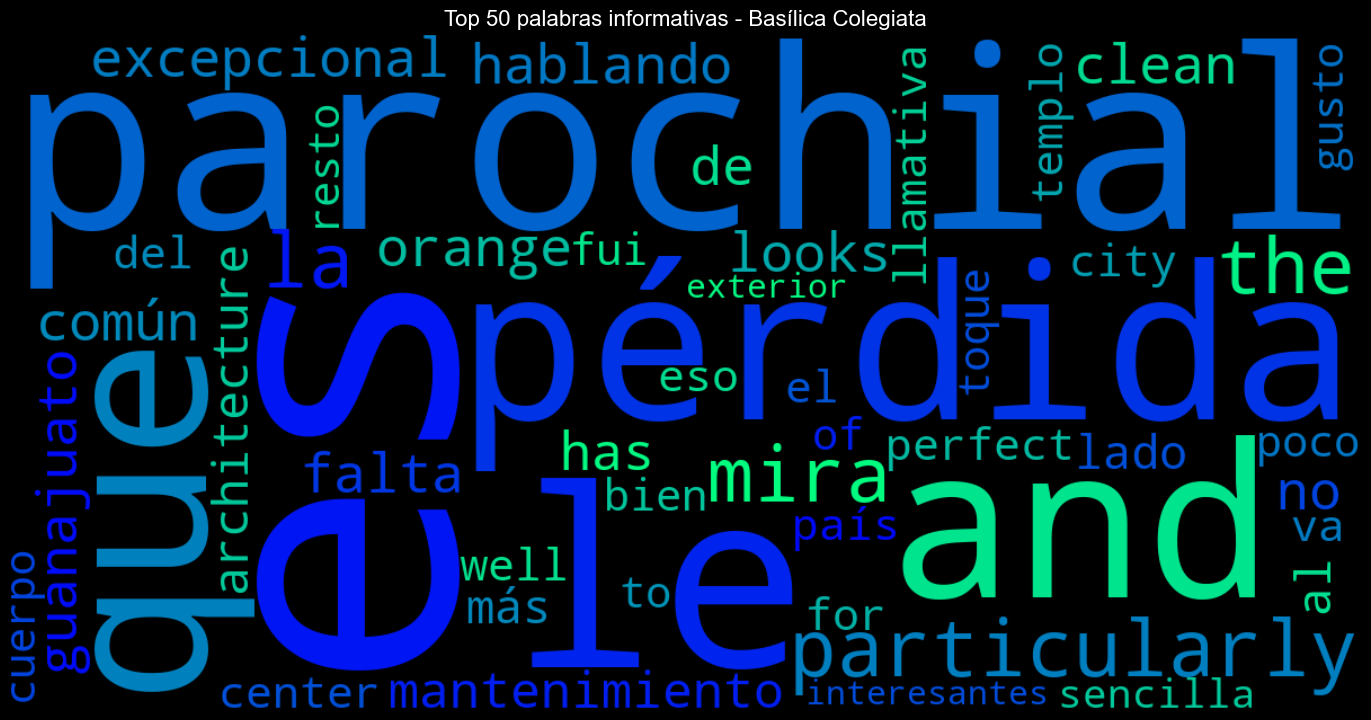

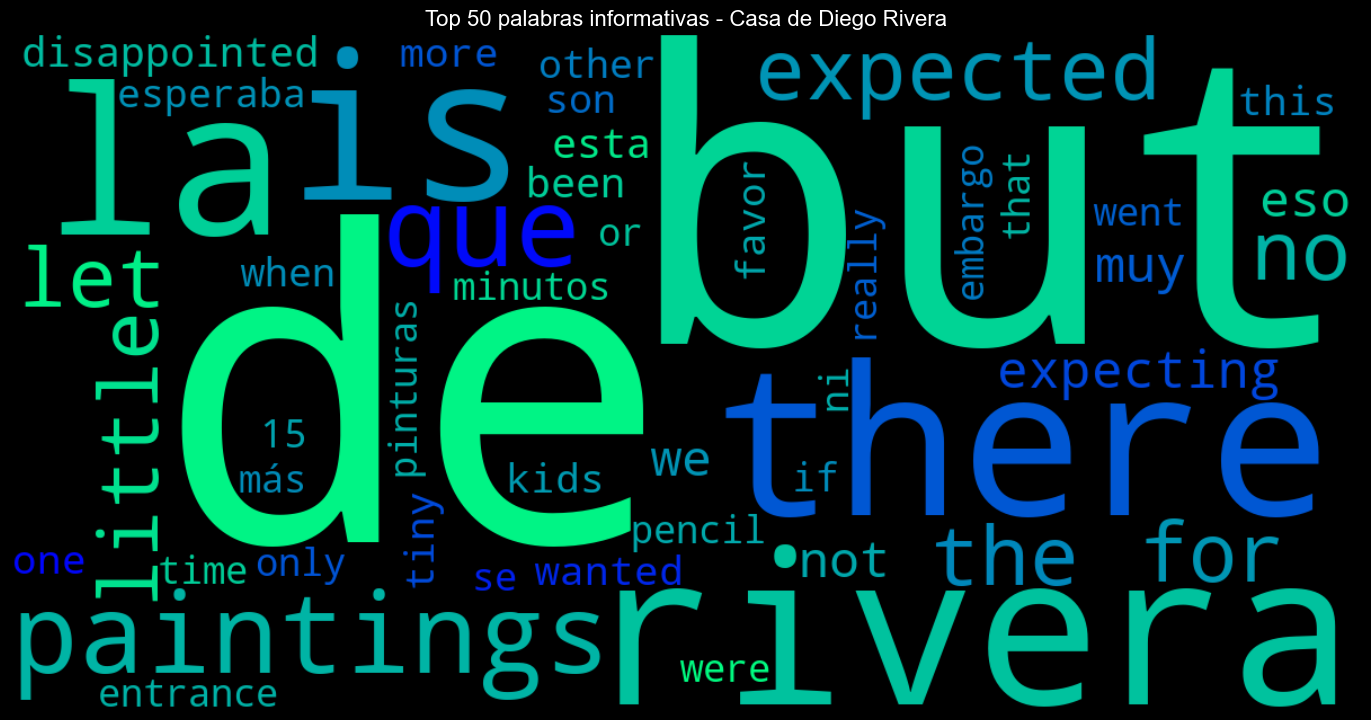

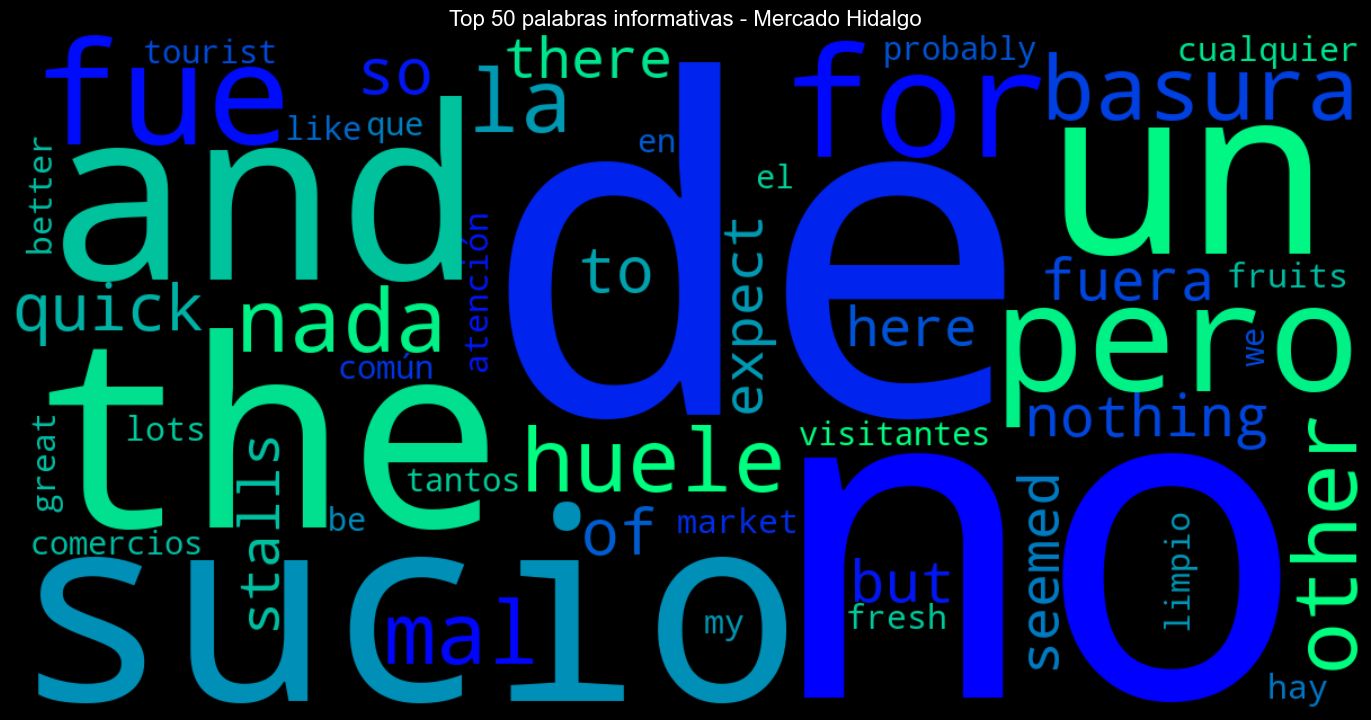

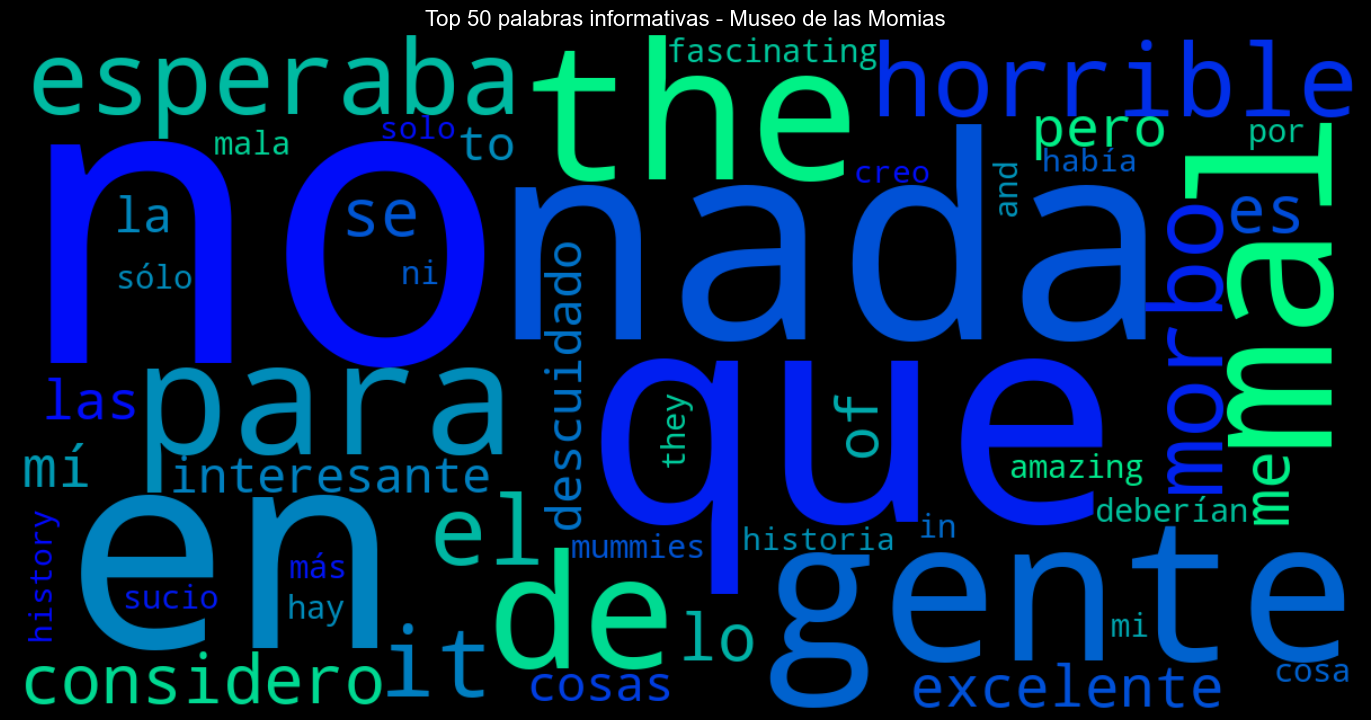

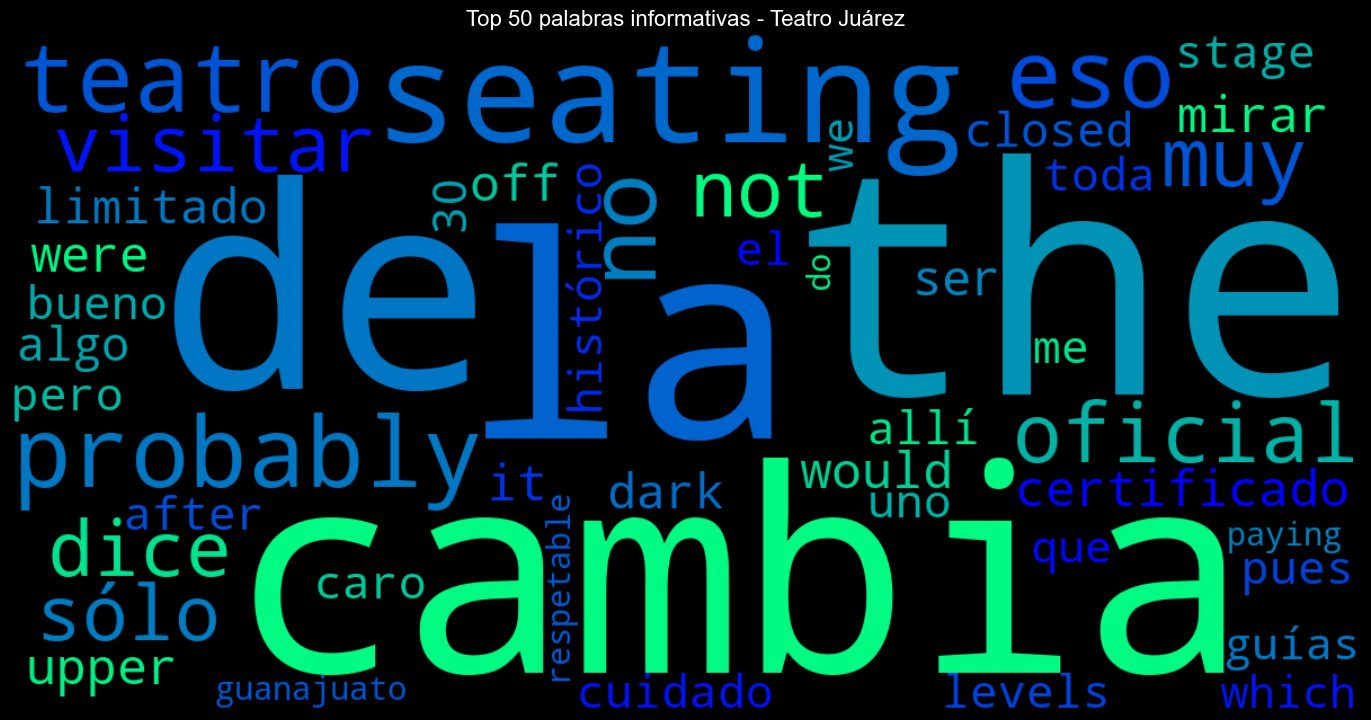

In [15]:
for analyzer in multi.analyzers:
    analyzer.plot_wordcloud(k = 50)

## **1.3.- (15pts) Para cada uno de los $10$ sitios turísticos, haga un descubrimiento automático de los $3$ tópicos con LSA (investiga, estudia y aprende por su cuenta LSA) más relevantes y $10$ palabras contenidas en cada tópico de cada uno de los siguientes subgrupos:**

**Antes de aplicar LSA, asegúrese de hacerlo sobre una matriz lo más grande posible (para su hardware) de TFIDF Normalizada a L2. Note que para cada sitio turístico deberá saber cuales son los 3 temas de interés y sus palabras, para cada uno de estos subgrupos. Recomiendo Gensim; para rápido y fácil. Otra sugerencia puede ser usar la función TruncatedSVD de sklearnt para obtener la descomposición de matrices como se sugiere en el siguiente video para implementar LSA: https://www.youtube.com/watch?v=hB51kkus-Rc. También podría llevar a cabo svd con numpy (si te sobra tiempo en la vida).**

### **a) Hombres**

### **b) Mujeres**

### **c) Turistas Nacionales**

### **d) Turistas Internacionales**

### **e) Jovénes (elige un rango de edad interesante con base en sus estadísticas)**

### **f) Mayores (elige un rango de edad interesante con base en sus estadísticas)**

## **1.4.- (15pts) Para cada uno de los 10 sitios turísticos construya tres Bolsas de Palabras de la siguiente manera: i) 1000 términos con mayor peso tfidf, ii) 2000 bigramas con mayor tfidf, y iii) 1000 trigramas con mayor tfidf. Luego concatene las tres representaciones que fueron calculadas de forma independiente, con sus propios tfidfs según su espacio y su propio L2. Finalmente sobre todo ese espacio concatenado de 4000 características aplique ganancia de información o X2 y obtenga los 1000 features más relevantes. Muestre una nube de palabras con el top 50 features relevantes para cada lugar turístico (10 nubes en total, quiero ver, para cada sitio, en la misma nube los mejores uni-bi-trigramas cuando se aplica feature selection en el espacio global).**

## **1.5.- (15pts) Diseñe un análisis temporal (formato libre) que muestre opiniones positivas, negativas y neutras a través de los meses y años para todos los sitios turísticos. En pocas palabras mostrar la evolución de las opiniones a través del tiempo.**

* * *
# **2.- Preguntas (50pts): Conteste lo más detallado posible lo siguiente, dando argumentos y conclusiones claras según su análisis previo. Cada respuesta entre 150 (mínimo) y 300 (máximo) palabras.**

## **2.1.- (10pts) ¿De los sitios turísticos, cual diría usted que es el más polémico y la razón de ello?**

## **2.2.- (10pts) En cuanto al sitio más polémico, ¿Como es la diferencia de opinión y temas entre turistas nacionales e internacionales?**

## **2.3.- (10pts) ¿Cual diría que es el sitio que le gusta más a las mujeres y por qué?**

## **2.4.- (10pts) ¿Cual diría que es el sitio que le gusta más a las personas jóvenes y por qué?**

## **2.5.- (10pts) ¿Qué otras observaciones valiosas puede obtener de su análisis? (e.g., ¿identificó de que se queja la gente? ¿qué tipo de cosas le gustó a la gente?, etc.)**